In [ ]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

con = duckdb.connect(database="greenium_transition.duckdb", read_only=False)

print("DuckDB Bağlantısı Başarılı!")

DuckDB Bağlantısı Başarılı!


In [16]:
# Create schemas for issuers and bonds based on LGX and CBI data standards

# 1. Issuers Table
con.execute(
    """
CREATE TABLE IF NOT EXISTS issuers (
    issuer_id VARCHAR PRIMARY KEY,
    issuer_name VARCHAR,
    sector VARCHAR,
    esg_score DOUBLE,
    carbon_intensity DOUBLE, -- CO2 emissions per revenue
    credit_rating VARCHAR
);
"""
)

# 2. Bonds Table
con.execute(
    """
CREATE TABLE IF NOT EXISTS bonds (
    isin VARCHAR PRIMARY KEY,
    issuer_id VARCHAR,
    bond_type VARCHAR, -- 'GREEN', 'VANILLA', 'SLB' (Sustainability-Linked)
    issue_date DATE,
    maturity_date DATE,
    coupon_rate DOUBLE,
    yield_to_maturity DOUBLE, -- YTM (%)
    amount_issued_usd DOUBLE,
    kpi_target_met BOOLEAN, -- Relevant for SLBs (Coupon Step-Up trigger)
    step_up_margin DOUBLE,  -- Penalty margin if KPI is missed (in bps)
    FOREIGN KEY (issuer_id) REFERENCES issuers(issuer_id)
);
"""
)

print("Tables successfully created in DuckDB!")

Tables successfully created in DuckDB!


In [17]:
# Generate realistic synthetic data reflecting Greenium and Transition Finance dynamics

np.random.seed(42)  # For reproducibility

# 1. Generate Issuers Data (50 Companies across various sectors)
n_issuers = 50
sectors = [
    "Energy",
    "Utilities",
    "Financials",
    "Industrials",
    "Technology",
    "Materials",
]
credit_ratings = ["AAA", "AA", "A", "BBB", "BB"]

issuers_data = []
for i in range(1, n_issuers + 1):
    issuer_id = f"ISSUER_{i:03d}"
    issuer_name = f"Global Corp {i}"
    sector = np.random.choice(sectors)
    esg_score = np.round(np.random.uniform(40, 95), 2)

    # Higher carbon intensity for Energy/Utilities/Materials
    if sector in ["Energy", "Utilities", "Materials"]:
        carbon_intensity = np.round(np.random.uniform(200, 800), 2)
    else:
        carbon_intensity = np.round(np.random.uniform(10, 200), 2)

    credit_rating = np.random.choice(credit_ratings, p=[0.1, 0.2, 0.4, 0.2, 0.1])

    issuers_data.append(
        (
            issuer_id,
            issuer_name,
            sector,
            esg_score,
            carbon_intensity,
            credit_rating,
        )
    )

df_issuers = pd.DataFrame(
    issuers_data,
    columns=[
        "issuer_id",
        "issuer_name",
        "sector",
        "esg_score",
        "carbon_intensity",
        "credit_rating",
    ],
)

# 2. Generate Bonds Data (Matched Pairs + SLBs)
bonds_data = []
bond_counter = 1

rating_base_yield = {
    "AAA": 3.5,
    "AA": 3.8,
    "A": 4.2,
    "BBB": 4.8,
    "BB": 5.8,
}  # Base yield levels (%)

for idx, issuer in df_issuers.iterrows():
    base_ytm = rating_base_yield[issuer["credit_rating"]]

    # Market dynamic: ESG Score reduces yield slightly, Carbon Intensity increases it
    esg_discount = (issuer["esg_score"] - 50) * 0.005
    carbon_premium = (issuer["carbon_intensity"] / 500) * 0.1
    adjusted_base_ytm = base_ytm - esg_discount + carbon_premium

    # --- A) Vanilla Bond ---
    isin_vanilla = f"US{bond_counter:09d}"
    bond_counter += 1
    vanilla_ytm = np.round(adjusted_base_ytm + np.random.normal(0, 0.05), 3)

    bonds_data.append(
        (
            isin_vanilla,
            issuer["issuer_id"],
            "VANILLA",
            "2022-01-15",
            "2032-01-15",
            np.round(vanilla_ytm - 0.2, 2),  # Coupon rate
            vanilla_ytm,
            np.random.choice([250e6, 500e6, 750e6, 1e9]),
            None,
            0.0,
        )
    )

    # --- B) Green Bond - Matched Pair with Greenium ---
    isin_green = f"US{bond_counter:09d}"
    bond_counter += 1

    # Behavioral Dynamic: Higher ESG = Larger Greenium (lower YTM)
    # Average Greenium ~ 5 to 20 bps (0.05% to 0.20%)
    greenium_bps = 0.05 + (issuer["esg_score"] / 100) * 0.15
    green_ytm = np.round(vanilla_ytm - greenium_bps, 3)

    bonds_data.append(
        (
            isin_green,
            issuer["issuer_id"],
            "GREEN",
            "2022-01-15",
            "2032-01-15",
            np.round(green_ytm - 0.2, 2),
            green_ytm,
            np.random.choice([250e6, 500e6, 750e6, 1e9]),
            None,
            0.0,
        )
    )

    # --- C) Sustainability-Linked Bond (SLB / Transition) ---
    # Issued mostly by high carbon/transition issuers
    if issuer["sector"] in ["Energy", "Utilities", "Materials", "Industrials"]:
        isin_slb = f"US{bond_counter:09d}"
        bond_counter += 1

        kpi_met = np.random.choice([True, False], p=[0.65, 0.35])
        step_up = 25.0  # Standard 25 bps step-up penalty in SLB market

        # If KPI target missed, yield increases due to penalty mechanism
        slb_ytm = vanilla_ytm - 0.03  # Slight transition discount initially
        if not kpi_met:
            slb_ytm += step_up / 100  # Penalty added to YTM

        slb_ytm = np.round(slb_ytm, 3)

        bonds_data.append(
            (
                isin_slb,
                issuer["issuer_id"],
                "SLB",
                "2022-03-01",
                "2032-03-01",
                np.round(slb_ytm - 0.2, 2),
                slb_ytm,
                np.random.choice([250e6, 500e6, 750e6]),
                kpi_met,
                step_up,
            )
        )

df_bonds = pd.DataFrame(
    bonds_data,
    columns=[
        "isin",
        "issuer_id",
        "bond_type",
        "issue_date",
        "maturity_date",
        "coupon_rate",
        "yield_to_maturity",
        "amount_issued_usd",
        "kpi_target_met",
        "step_up_margin",
    ],
)

# 3. Write DataFrames directly to DuckDB
con.execute("DELETE FROM bonds;")
con.execute("DELETE FROM issuers;")

con.register("df_issuers_temp", df_issuers)
con.execute("INSERT INTO issuers SELECT * FROM df_issuers_temp;")

con.register("df_bonds_temp", df_bonds)
con.execute("INSERT INTO bonds SELECT * FROM df_bonds_temp;")

print("Data successfully generated and loaded into DuckDB!")
print(f"Total Issuers: {con.execute('SELECT COUNT(*) FROM issuers').fetchone()[0]}")
print(f"Total Bonds: {con.execute('SELECT COUNT(*) FROM bonds').fetchone()[0]}")

Data successfully generated and loaded into DuckDB!
Total Issuers: 50
Total Bonds: 134


In [18]:
# SQL Query 1: Calculate Greenium for matched pairs (Green vs Vanilla)
# Greenium = Yield(Vanilla) - Yield(Green) in basis points (bps)

query_greenium = """
SELECT 
    v.issuer_id,
    i.issuer_name,
    i.sector,
    i.esg_score,
    i.carbon_intensity,
    v.yield_to_maturity AS vanilla_ytm,
    g.yield_to_maturity AS green_ytm,
    ROUND((v.yield_to_maturity - g.yield_to_maturity) * 100, 2) AS greenium_bps
FROM bonds v
JOIN bonds g ON v.issuer_id = g.issuer_id
JOIN issuers i ON v.issuer_id = i.issuer_id
WHERE v.bond_type = 'VANILLA' AND g.bond_type = 'GREEN'
ORDER BY greenium_bps DESC;
"""

df_greenium = con.execute(query_greenium).df()

print("--- Greenium Summary (Top 5 Highest Greenium) ---")
print(df_greenium.head(5))

--- Greenium Summary (Top 5 Highest Greenium) ---
    issuer_id     issuer_name       sector  esg_score  carbon_intensity  \
0  ISSUER_040  Global Corp 40       Energy      94.88            360.07   
1  ISSUER_001   Global Corp 1  Industrials      92.29            149.08   
2  ISSUER_010  Global Corp 10  Industrials      91.82            117.02   
3  ISSUER_004   Global Corp 4  Industrials      91.62             10.15   
4  ISSUER_029  Global Corp 29  Industrials      89.92             57.37   

   vanilla_ytm  green_ytm  greenium_bps  
0        5.677      5.485          19.2  
1        4.112      3.924          18.8  
2        4.013      3.825          18.8  
3        5.633      5.446          18.7  
4        3.966      3.781          18.5  


In [19]:
# SQL Query 2: Analyze Transition Finance (SLBs) and Step-Up Penalty dynamics

query_slb = """
SELECT 
    b.isin,
    i.issuer_name,
    i.sector,
    i.carbon_intensity,
    b.coupon_rate,
    b.yield_to_maturity AS slb_ytm,
    b.kpi_target_met,
    b.step_up_margin AS penalty_bps
FROM bonds b
JOIN issuers i ON b.issuer_id = i.issuer_id
WHERE b.bond_type = 'SLB'
ORDER BY b.kpi_target_met ASC, i.carbon_intensity DESC;
"""

df_slb = con.execute(query_slb).df()

print("--- Transition Finance (SLB) Penalty Analysis (First 5 Rows) ---")
print(df_slb.head(5))

--- Transition Finance (SLB) Penalty Analysis (First 5 Rows) ---
          isin     issuer_name       sector  carbon_intensity  coupon_rate  \
0  US000000015   Global Corp 5       Energy            514.85         4.26   
1  US000000131  Global Corp 49       Energy            432.04         5.78   
2  US000000046  Global Corp 16    Materials            227.14         4.26   
3  US000000092  Global Corp 34  Industrials            182.30         3.80   
4  US000000028  Global Corp 10  Industrials            117.02         4.03   

   slb_ytm  kpi_target_met  penalty_bps  
0    4.455           False         25.0  
1    5.984           False         25.0  
2    4.460           False         25.0  
3    4.001           False         25.0  
4    4.233           False         25.0  


In [20]:
# Econometric Modeling: Ordinary Least Squares (OLS) Regression for Greenium
# Target Variable (Y): Greenium in basis points (bps)
# Explanatory Variables (X): ESG Score, Carbon Intensity

# 1. Prepare data for OLS model from our DuckDB Greenium query
df_reg = df_greenium.copy()

# 2. Fit the OLS model using statsmodels formula syntax
model_greenium = smf.ols(
    formula="greenium_bps ~ esg_score + carbon_intensity", data=df_reg
).fit()

# 3. Display the econometric summary output
print("--- Greenium Behavioral Model Summary ---")
print(model_greenium.summary())

--- Greenium Behavioral Model Summary ---
                            OLS Regression Results                            
Dep. Variable:           greenium_bps   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.900e+05
Date:                Sun, 06 Sep 2026   Prob (F-statistic):           1.47e-92
Time:                        17:55:51   Log-Likelihood:                 112.36
No. Observations:                  50   AIC:                            -218.7
Df Residuals:                      47   BIC:                            -213.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

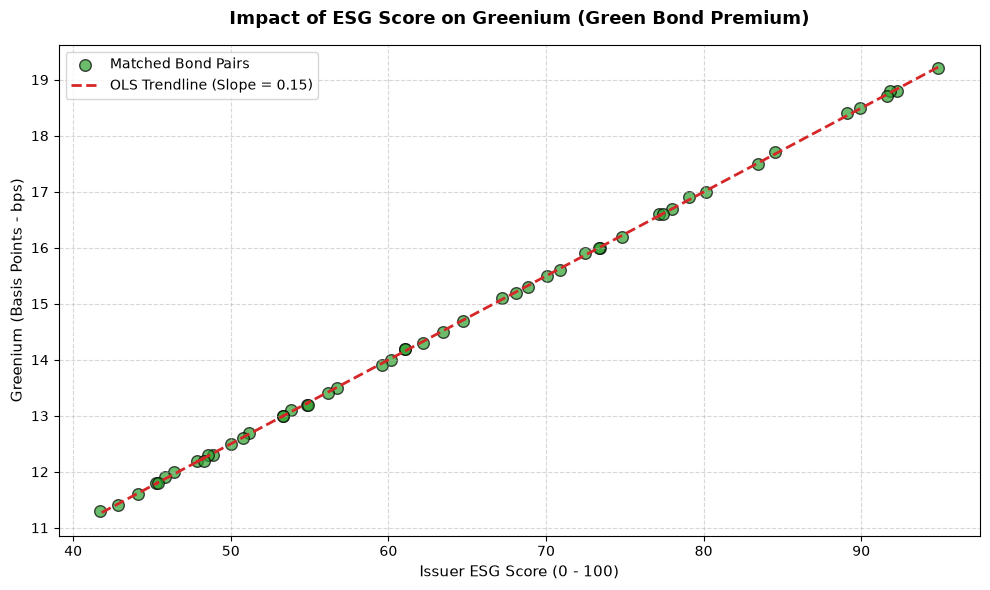

In [21]:
# Publication-Ready Visualization 1: ESG Score vs Greenium Scatter Plot
plt.figure(figsize=(10, 6))

# Plot scatter points
plt.scatter(
    df_greenium["esg_score"],
    df_greenium["greenium_bps"],
    color="#2ca02c",
    alpha=0.7,
    edgecolors="k",
    s=70,
    label="Matched Bond Pairs",
)

# Plot OLS regression line
slope, intercept = np.polyfit(
    df_greenium["esg_score"], df_greenium["greenium_bps"], 1
)
plt.plot(
    df_greenium["esg_score"],
    slope * df_greenium["esg_score"] + intercept,
    color="#d62728",
    linestyle="--",
    linewidth=2,
    label=f"OLS Trendline (Slope = {slope:.2f})",
)

# Chart styling and labels
plt.title(
    "Impact of ESG Score on Greenium (Green Bond Premium)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Issuer ESG Score (0 - 100)", fontsize=11)
plt.ylabel("Greenium (Basis Points - bps)", fontsize=11)
plt.legend(loc="upper left", frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

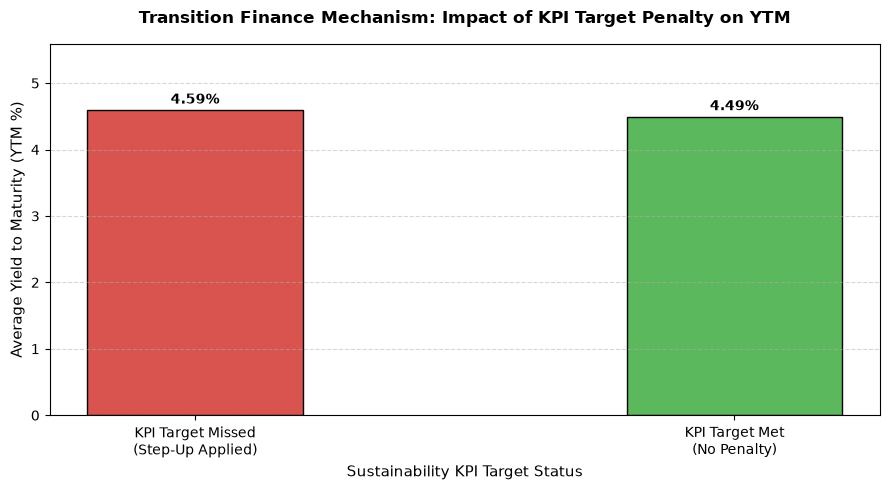

In [22]:
# Publication-Ready Visualization 2: SLB KPI Target Met vs Yield (Coupon Step-Up Effect)
plt.figure(figsize=(9, 5))

# Group data by KPI Met status and calculate average YTM
df_slb_summary = (
    df_slb.groupby("kpi_target_met")["slb_ytm"].mean().reset_index()
)
df_slb_summary["status_label"] = df_slb_summary["kpi_target_met"].map(
    {True: "KPI Target Met\n(No Penalty)", False: "KPI Target Missed\n(Step-Up Applied)"}
)

colors = ["#d9534f" if not status else "#5cb85c" for status in df_slb_summary["kpi_target_met"]]

bars = plt.bar(
    df_slb_summary["status_label"],
    df_slb_summary["slb_ytm"],
    color=colors,
    width=0.4,
    edgecolor="black",
)

# Annotate YTM values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.05,
        f"{yval:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

# Chart styling and labels
plt.title(
    "Transition Finance Mechanism: Impact of KPI Target Penalty on YTM",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Sustainability KPI Target Status", fontsize=11)
plt.ylabel("Average Yield to Maturity (YTM %)", fontsize=11)
plt.ylim(0, max(df_slb_summary["slb_ytm"]) + 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()